# Euclid Lensed-AGN Forecast
Wide survey: 14500 deg$^2$, second-brightest-image cut at the VIS 5$\sigma$ depth (26.2 mag),
image separation 0.2''–4.0''. The Y/J/H magnitudes of every image are kept in the catalog, so
the NISP 5$\sigma$ depth (24.5 mag) is applied afterwards as a sub-selection.

Source redshifts are limited to $z_S < 3$ because the SkyPy/kcorrect host-galaxy templates are
not defined blueward of the Euclid filters above that redshift.

In [1]:
import os
import gzip
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from astropy.table import Table, vstack
from astropy.units import Quantity
from IPython.display import display

import slsim
import slsim.Pipelines as pipelines
from slsim.Deflectors.DeflectorPopulation.galaxy_deflectors import GalaxyDeflectors
from slsim.Lenses.LensPopulation.lens_pop import LensPop
from slsim.Sources.SourceCatalogues.QuasarCatalog.quasar_pop import QuasarRate
# from slsim.Sources.SourcePopulation.point_plus_extended_sources import PointPlusExtendedSources
from slsim.Sources.SourcePopulation.point_sources import PointSources
from slsim.Sources.SourceVariability.agn import agn_bounds_dict

from utils import extract_lensed_agn_properties, plot_montage, plot_euclid_montage, plot_survey_corner

warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

In [2]:
DATA_DIR = "./data"
FIGURE_DIR = "./figures"

EUCLID_BANDS = ["VIS", "Y", "J", "H"]
VIS_DEPTH = 26.2
NISP_DEPTH = 24.5

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
skypy_config = os.path.join(
    os.path.dirname(os.path.dirname(slsim.__file__)), "data/SkyPy/euclid-like.yml"
)
base_sky_area = Quantity(value=10, unit="deg2")
quasar_catalog_path = os.path.join(DATA_DIR, "euclid_quasar_source_catalog_PS.fits")

## 1. Deflector and source populations

In [3]:
galaxy_pipeline = pipelines.SkyPyPipeline(
    skypy_config=skypy_config, sky_area=base_sky_area, filters=None,
    cosmo=cosmo, z_min=0.0, z_max=3.0,
)
host_galaxy_candidates = vstack(
    [galaxy_pipeline.red_galaxies, galaxy_pipeline.blue_galaxies], join_type="exact"
)

lens_galaxies = GalaxyDeflectors(
    red_galaxy_list=galaxy_pipeline.red_galaxies,
    blue_galaxy_list=galaxy_pipeline.blue_galaxies,
    kwargs_cut={"band": "VIS", "band_max": 28, "z_min": 0.01, "z_max": 2.5},
    kwargs_mass2light={}, cosmo=cosmo, sky_area=base_sky_area,
    gamma_pl={"mean": 2.078, "std_dev": 0.16},
)

In [4]:
if os.path.exists(quasar_catalog_path):
    quasar_source = Table.read(quasar_catalog_path)
else:
    quasar_source = QuasarRate(
        # skypy_config=skypy_config, 
        cosmo=cosmo, sky_area=base_sky_area, noise=True,
        redshifts=np.linspace(0.001, 5.01, 100),
        # host_galaxy_candidate=host_galaxy_candidates,
        use_qsogen_sed=True, qsogen_bands=EUCLID_BANDS, use_sed_interpolator=True,
    ).quasar_sample(m_min=15, m_max=30, host_galaxy=False)
    quasar_source.write(quasar_catalog_path, overwrite=True)



In [5]:
source_quasar = PointSources(
    point_source_list=quasar_source, cosmo=cosmo, sky_area=base_sky_area,
    kwargs_cut={"band": "VIS", "band_max": 28, "z_min": 0.001, "z_max": 5.0},
    point_source_type="quasar",
)

In [6]:
quasar_source

z,M_i,ps_mag_i,ps_mag_VIS,ps_mag_Y,ps_mag_J,ps_mag_H
float64,float64,float64,float64,float64,float64,float64
2.6733058817920896,-23.156811947270718,22.699280982619257,22.66608177299635,22.35187784155707,22.40696599710448,22.365038636965373
2.213978540095596,-16.910254266382562,28.50540477574676,28.510228484994105,28.209994256974767,28.25574193997597,28.216133582919255
1.0334680339650515,-13.65266976021199,29.96749154582042,29.978415692016345,29.95002367316564,29.60999462462591,30.001709279239087
1.0333885180302627,-16.146258400373494,27.473775785979488,27.477120659389325,27.454450775188853,27.12776818330617,27.49736853943219
0.626425179895944,-12.607134219613204,29.839860233204522,29.919834327227232,29.485967488048093,29.93467522965728,29.712488035429942
3.348085476620237,-20.886805056014744,25.50217539574152,25.491002576106844,25.223625935271567,25.045895938746913,25.133325229444473
2.221293175906685,-16.673282532390825,28.7524431111131,28.755394502215267,28.448999737523003,28.498876992432017,28.45714920341526
2.5808203706777983,-19.87424969193132,25.939948076489497,25.8356320948464,25.492840505727074,25.553923547416645,25.516144009654305
0.3756645038333394,-11.632680775087906,29.692365951983195,29.427849606249552,29.621428364828077,29.464604128776585,29.249096360883954


## 2. Draw the Euclid wide-survey population

In [7]:
survey_data = {
    "Euclid_Wide": {
        "name": "Euclid Wide",
        "sky_area": Quantity(value=14500, unit="deg2"),
        "kwargs_lens_cuts": {
            "min_image_separation": 0.2,
            "max_image_separation": 4.0,
            "second_brightest_image_cut": {"VIS": VIS_DEPTH},
        },
        "catalog_savepath": os.path.join(DATA_DIR, "euclid_wide_lensed_agn_catalog_PS.fits"),
    },
}

In [9]:
for data in survey_data.values():
    lens_pop = LensPop(
        deflector_population=lens_galaxies, source_population=source_quasar,
        cosmo=cosmo, sky_area=data["sky_area"],
    )
    data["lens_objects"] = lens_pop.draw_population(
        speed_factor=10000, kwargs_lens_cuts=data["kwargs_lens_cuts"], verbose=True
    )
    data["catalog"] = extract_lensed_agn_properties(
        data["lens_objects"], all_bands=EUCLID_BANDS, max_num_images=5
    )
    print(f"{data['name']}: {len(data['catalog'])} lensed AGNs")

    data["catalog"].write(data["catalog_savepath"], format="fits", overwrite=True)
    with gzip.open(data["catalog_savepath"].replace(".fits", "_lens_objects.pkl.gz"), "wb") as f:
        pickle.dump(data["lens_objects"], f)

Euclid Wide: 16816 lensed AGNs


## 3. NISP-detected sub-sample and summary

In [10]:
wide = survey_data["Euclid_Wide"]
nisp_detected = np.all(
    [wide["catalog"][f"second_brightest_image_ps_mag_{b}"] < NISP_DEPTH for b in ["Y", "J", "H"]],
    axis=0,
)

survey_data["Euclid_Wide_NISP"] = {
    "name": "Euclid Wide (VIS+NISP)",
    "sky_area": wide["sky_area"],
    "kwargs_lens_cuts": {
        "min_image_separation": 0.2,
        "max_image_separation": 4.0,
        "second_brightest_image_cut": {"VIS": VIS_DEPTH, "Y": NISP_DEPTH, "J": NISP_DEPTH, "H": NISP_DEPTH},
    },
    "catalog": wide["catalog"][nisp_detected],
    "lens_objects": [l for l, keep in zip(wide["lens_objects"], nisp_detected) if keep],
}

In [11]:
summary_rows = []
for data in survey_data.values():
    catalog = data["catalog"]
    n_quads = int(np.sum(catalog["num_images"] == 4))
    n_doubles = int(np.sum(catalog["num_images"] == 2))
    cuts = data["kwargs_lens_cuts"]
    summary_rows.append({
        "Survey": data["name"],
        "Sky Area (deg²)": f"{data['sky_area'].value:,.0f}",
        "Total Lensed-AGN": f"{len(catalog):,}",
        "Doubles": f"{n_doubles:,}",
        "Quads": f"{n_quads:,}",
        "Quad Fraction": f"{n_quads / max(len(catalog), 1):.1%}",
        "Image Sep Cuts (\")": f"{cuts['min_image_separation']} - {cuts['max_image_separation']}",
        "Mag Cuts (2nd Brightest Image)": ", ".join(
            f"{b} < {m}" for b, m in cuts["second_brightest_image_cut"].items()
        ),
    })

display(pd.DataFrame(summary_rows).set_index("Survey"))

,Sky Area (deg²),Total Lensed-AGN,Doubles,Quads,Quad Fraction,"Image Sep Cuts ("")",Mag Cuts (2nd Brightest Image)
Survey,,,,,,,
Euclid Wide,"14,500","16,816","14,715","1,642",9.8%,0.2 - 4.0,VIS < 26.2
Euclid Wide (VIS+NISP),"14,500","7,491","6,356",910,12.1%,0.2 - 4.0,"VIS < 26.2, Y < 24.5, J < 24.5, H < 24.5"


## 4. Population properties

Saved figure to: ./figures/corner_euclid_wide_PS.png


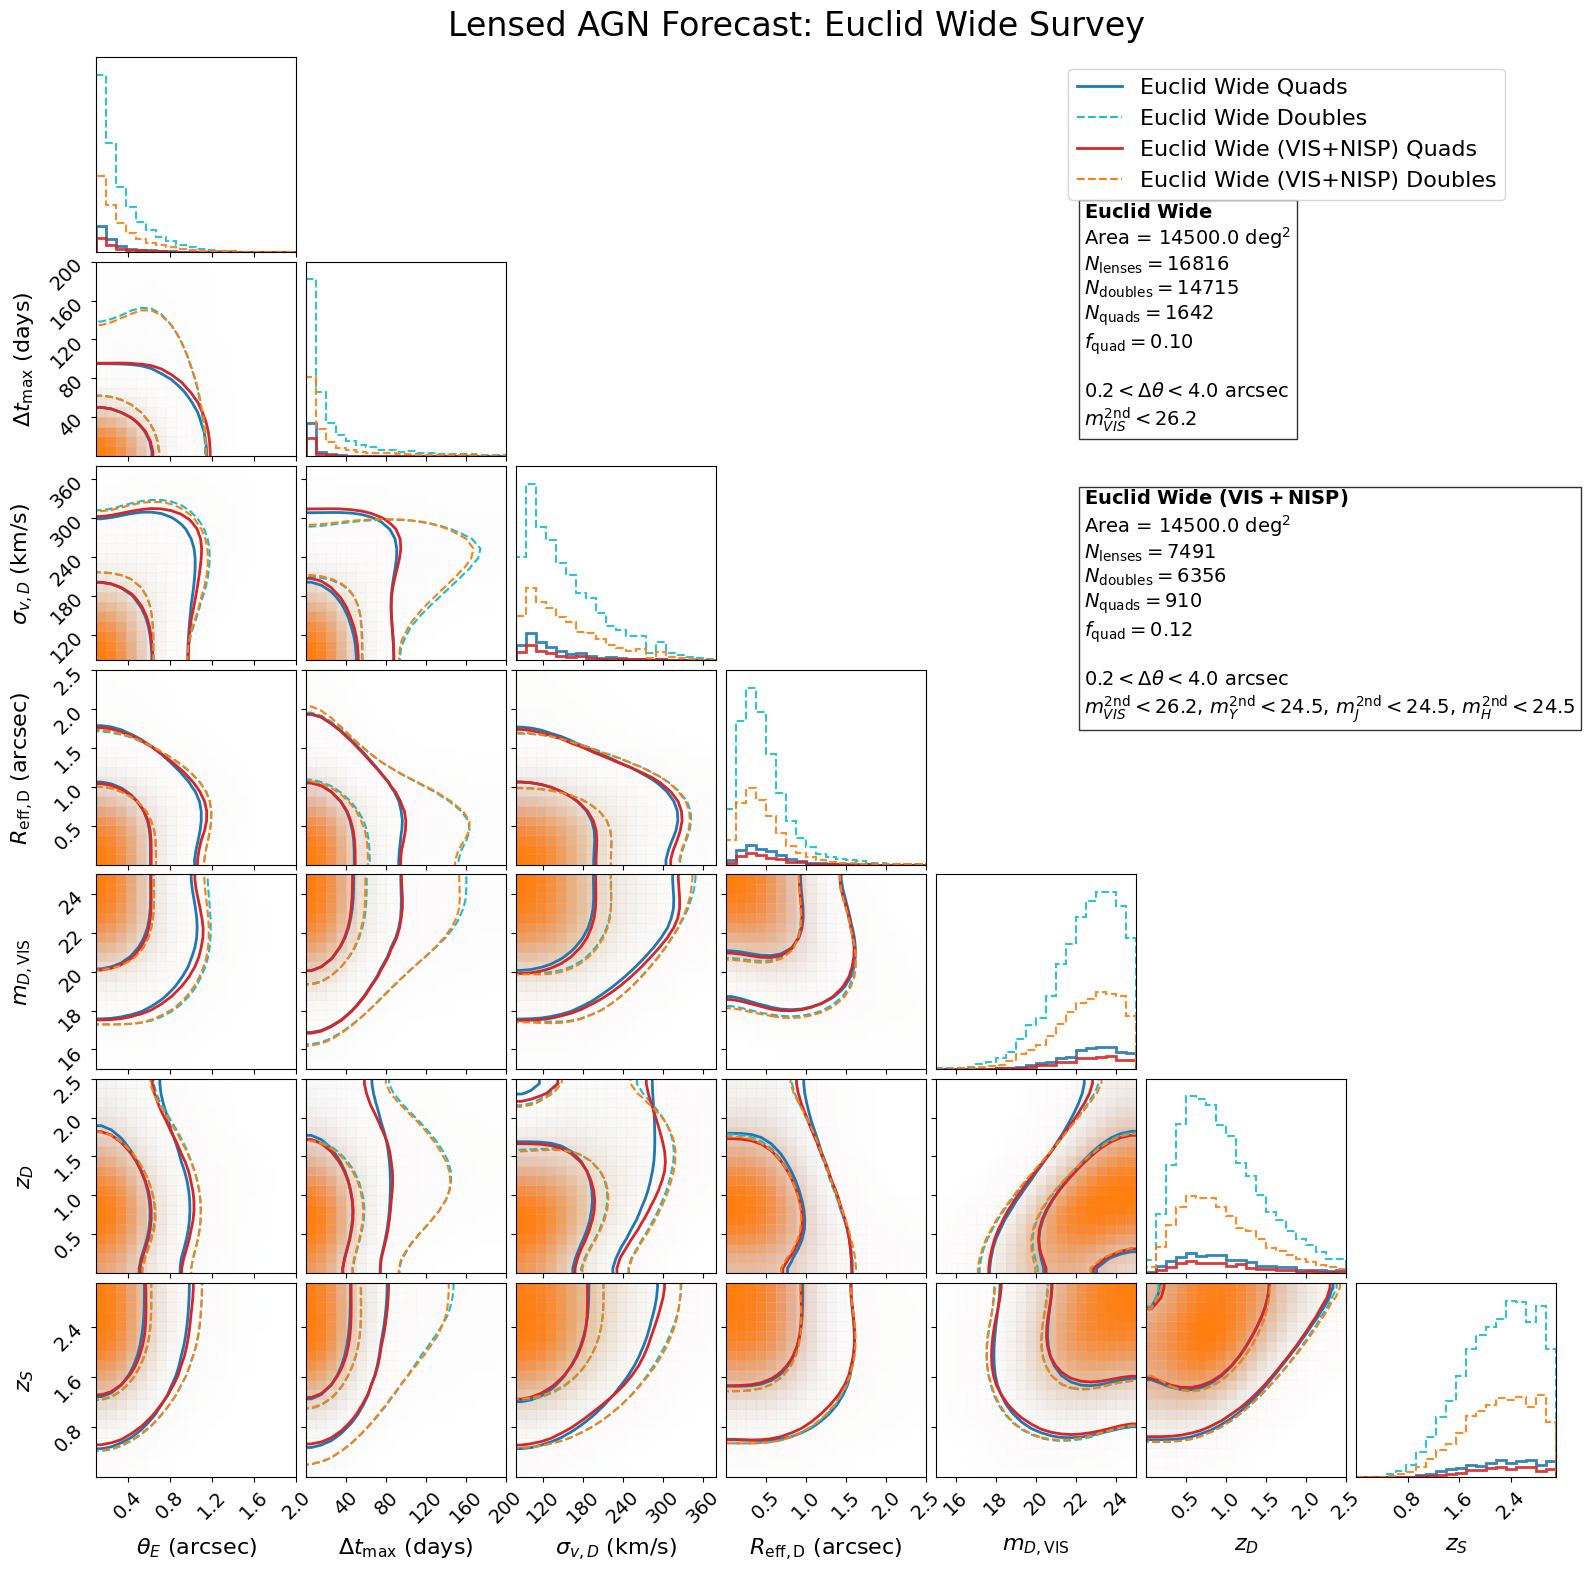

In [13]:
plot_params = [
    "theta_E_arcsec", "max_time_delay_days", "deflector_velocity_dispersion",
    "deflector_light_R_eff_arcsec", "deflector_mag_VIS", "z_D", "z_S",
]
latex_labels = [
    r"$\theta_E$ (arcsec)", r"$\Delta t_{\max}$ (days)", r"$\sigma_{v, D}$ (km/s)",
    r"$R_{\rm eff, D}$ (arcsec)", r"$m_{D, \rm VIS}$", r"$z_D$", r"$z_S$",
]
range_vals = {
    "theta_E_arcsec": (0.1, 2.0),
    "max_time_delay_days": (0, 200),
    "deflector_velocity_dispersion": (80, 380),
    "deflector_light_R_eff_arcsec": (0, 2.5),
    "deflector_mag_VIS": (15, 25),
    "z_D": (0, 2.5),
    "z_S": (0, 3.1),
}

fig = plot_survey_corner(
    survey_data=survey_data,
    keys_to_plot=["Euclid_Wide", "Euclid_Wide_NISP"],
    params=plot_params, latex_labels=latex_labels, range_vals=range_vals,
    color_map={
        "Euclid_Wide": {"quads": "tab:blue", "doubles": "tab:cyan"},
        "Euclid_Wide_NISP": {"quads": "tab:red", "doubles": "tab:orange"},
    },
    title="Lensed AGN Forecast: Euclid Wide Survey",
    figsize=(16, 16), smooth=3, separate_quads_doubles=True,
    text_x=0.68, text_y_start=0.72, text_y_step=0.18,
    save_path=os.path.join(FIGURE_DIR, "corner_euclid_wide_PS.png"),
)
plt.show()

## 5. Euclid RGB montage

In [14]:
fig = plot_euclid_montage(
    lenses=wide["lens_objects"],
    number_to_plot=min(100, len(wide["lens_objects"])),
    num_cols=5, num_pix_vis=50,
    colour="VIS_WEIGHTED_Y_J_H", stretch="arcsinh",
    plot_title="Sample Lensed AGNs from Euclid Wide (VIS + Y/J/H)",
    random_seed=42,
)
if fig is not None:
    fig.savefig(os.path.join(FIGURE_DIR, "montage_Euclid_Wide_PS.png"), dpi=300, bbox_inches="tight")
    plt.show()

ValueError: band Y not supported! Choose 'VIS'.

In [17]:
fig = plot_montage(
    lenses=wide["lens_objects"],
    number_to_plot=min(200, len(wide["lens_objects"])),
    num_cols=20, num_pix=50,
    bands = ['VIS'],
    rgb_bands = ['VIS', 'VIS', 'VIS'],
    observatory = "Euclid",
    plot_title="Sample Lensed AGNs from Euclid Wide (VIS + Y/J/H)",
    random_seed=42,
)
if fig is not None:
    fig.savefig(os.path.join(FIGURE_DIR, "montage_Euclid_Wide_VIS_PS.png"), dpi=300, bbox_inches="tight")
    plt.show()

TypeError: SimAPI.__init__() got an unexpected keyword argument 'num_pix'. Did you mean 'numpix'?